# nlp-intraday-volatility-prediction

**Author:** Sana Ur Rehman  
**Profession:** Data Scientist  
**Created:** 2026  

---

## License

This project is licensed under the **MIT License**. 

You are free to use, modify, distribute, and build upon this work for both commercial and non-commercial purposes, provided you give appropriate **credit** to the original author. For the full legal text and conditions, please refer to the `LICENSE` file included in this project's repository.

---

## Citation

If you reference or build upon this project, please provide appropriate credit.

For formal citation information, please see the project's `README.md` and `CITATION.cff` files.

📍 Project Root: c:\Users\Yahya\Desktop\My folder\WQU\10. Capstone\Thesis Work\Machine Learning & Deep Learning in Finance\NLP for Intraday Volatility Prediction

📥 Downloading SPY data (Interval: 5m, Period: 60d)...


C:\Users\Yahya\AppData\Local\Temp\ipykernel_8212\3813696411.py:45: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_market = yf.download(tickers=TICKER, period=PERIOD, interval=INTERVAL, progress=False)


✅ Download Complete. Shape: (4604, 5)

📊 Plot saved to: c:\Users\Yahya\Desktop\My folder\WQU\10. Capstone\Thesis Work\Machine Learning & Deep Learning in Finance\NLP for Intraday Volatility Prediction\images\intraday_volatility_sample.png
💾 Processed Data saved to: c:\Users\Yahya\Desktop\My folder\WQU\10. Capstone\Thesis Work\Machine Learning & Deep Learning in Finance\NLP for Intraday Volatility Prediction\data\market_data_processed.csv

--- Data Preview ---
Price                 timestamp       close  log_return  rolling_volatility
12    2025-10-22 10:30:00-04:00  669.359985   -0.000105            0.000778
13    2025-10-22 10:35:00-04:00  669.049988   -0.000463            0.000675
14    2025-10-22 10:40:00-04:00  668.559998   -0.000733            0.000627
15    2025-10-22 10:45:00-04:00  668.869995    0.000464            0.000664
16    2025-10-22 10:50:00-04:00  669.190002    0.000478            0.000662


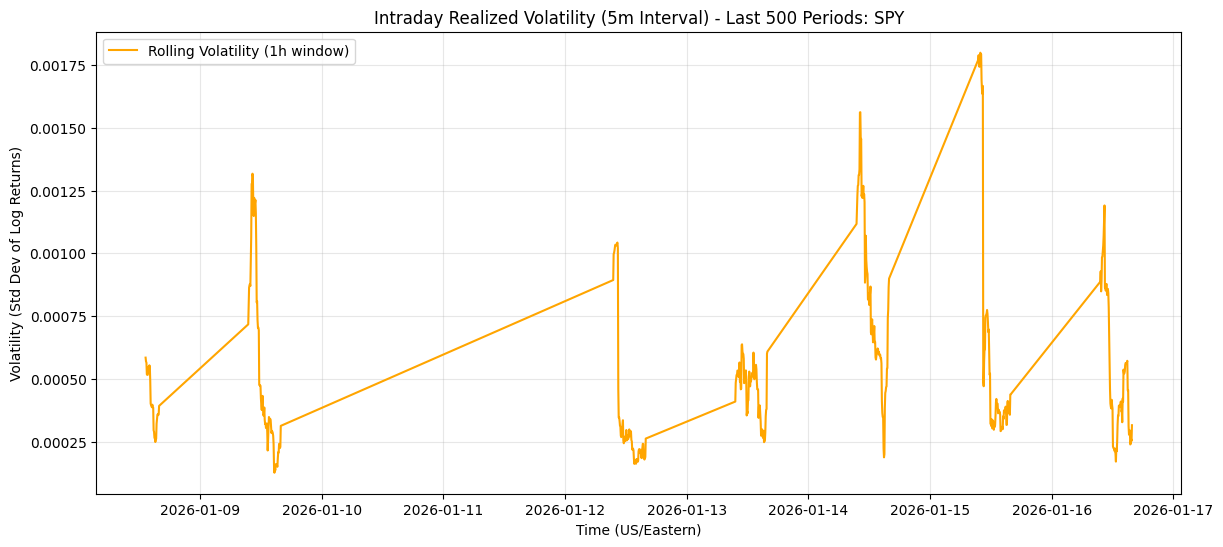

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ==========================================
# 1. PATH CONFIGURATION
# ==========================================

REQUIRED_FOLDERS = ['data', 'code', 'models', 'images', 'output']

def get_project_root():
    current_path = Path.cwd()
    if current_path.name in REQUIRED_FOLDERS:
        return current_path.parent
    return current_path

BASE_PATH = get_project_root()
DATA_PATH = BASE_PATH / 'data'
IMAGE_PATH = BASE_PATH / 'images'

# Create folders if they don't exist
for folder in REQUIRED_FOLDERS:
    (BASE_PATH / folder).mkdir(parents=True, exist_ok=True)

print(f"Project Root: {BASE_PATH}")

# ==========================================
# 2. DATA PARAMETERS
# ==========================================
TICKER = "SPY"  # S&P 500 ETF - Highly liquid, news-sensitive
INTERVAL = "5m" # 5-minute intraday bars
PERIOD = "60d"  # Max available for free yfinance intraday

# ==========================================
# 3. MARKET DATA ACQUISITION
# ==========================================
print(f"\nDownloading {TICKER} data (Interval: {INTERVAL}, Period: {PERIOD})...")

try:
    df_market = yf.download(tickers=TICKER, period=PERIOD, interval=INTERVAL, progress=False)
    
    # Flatten MultiIndex columns if necessary (common yfinance issue)
    if isinstance(df_market.columns, pd.MultiIndex):
        df_market.columns = df_market.columns.get_level_values(0)
    
    print(f"Download Complete. Shape: {df_market.shape}")
    
except Exception as e:
    print(f"Error downloading data: {e}")
    sys.exit()

# ==========================================
# 4. PREPROCESSING & TARGET GENERATION
# ==========================================
# Reset index to make Datetime a column for easier processing
df_market.reset_index(inplace=True)
df_market.rename(columns={'Datetime': 'timestamp', 'Close': 'close', 'Open': 'open', 'High': 'high', 'Low': 'low', 'Volume': 'volume'}, inplace=True)

# Ensure timestamp is localized to UTC then converted to US/Eastern (Market Time)
if df_market['timestamp'].dt.tz is None:
    df_market['timestamp'] = df_market['timestamp'].dt.tz_localize('UTC')
df_market['timestamp'] = df_market['timestamp'].dt.tz_convert('US/Eastern')

# Calculate Log Returns
# r_t = ln(P_t / P_{t-1})
df_market['log_return'] = np.log(df_market['close'] / df_market['close'].shift(1))

# Drop NaN created by shift
df_market.dropna(inplace=True)

# ==========================================
# 5. CALCULATING REALIZED VOLATILITY (rv)
# ==========================================
# We group by Date to calculate Daily Realized Volatility based on intraday 5-min returns.
# However, for Intraday prediction, we might want rolling volatility.
# Let's calculate a Rolling Volatility Window (e.g., rolling standard deviation of last 1 hour)
# 1 hour = 12 periods of 5 minutes.

WINDOW_SIZE = 12 

# Rolling Volatility (scaled to annualize? No, keep it raw for ML first)
# Standard deviation of returns * sqrt(Window) is a common proxy.
df_market['rolling_volatility'] = df_market['log_return'].rolling(window=WINDOW_SIZE).std()

# Target Variable: Next Step Volatility
# We want to predict volatility t+1 based on information at t.
df_market['target_volatility'] = df_market['rolling_volatility'].shift(-1) # The thing we want to predict

df_market.dropna(inplace=True)

# ==========================================
# 6. VISUALIZATION
# ==========================================
plt.figure(figsize=(14, 6))
plt.plot(df_market['timestamp'][-500:], df_market['rolling_volatility'][-500:], label='Rolling Volatility (1h window)', color='orange', linewidth=1.5)
plt.title(f'Intraday Realized Volatility (5m Interval) - Last 500 Periods: {TICKER}')
plt.ylabel('Volatility (Std Dev of Log Returns)')
plt.xlabel('Time (US/Eastern)')
plt.legend()
plt.grid(True, alpha=0.3)

# Save Plot
plot_path = IMAGE_PATH / 'intraday_volatility_sample.png'
plt.savefig(plot_path)
print(f"\nPlot saved to: {plot_path}")

# ==========================================
# 7. EXPORT DATA
# ==========================================
# Save to CSV
csv_path = DATA_PATH / 'market_data_processed.csv'
df_market.to_csv(csv_path, index=False)
print(f" Processed Data saved to: {csv_path}")

# Display first few rows
print("\n--- Data Preview ---")
print(df_market[['timestamp', 'close', 'log_return', 'rolling_volatility']].head())